In [17]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [18]:
iris = load_iris()
X = iris.data
y = iris.target.reshape(-1, 1)
classes = iris.target_names
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2,
random_state=42)

In [19]:
def create_mlp(input_dim, output_dim, hidden_layers, activation='relu'):
    model = Sequential()
    model.add(Dense(hidden_layers[0], input_dim=input_dim, activation=activation))
    for units in hidden_layers[1:]:
        model.add(Dense(units, activation=activation))
    model.add(Dense(output_dim, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [20]:
hidden_layer_configs = [[8], [16, 8], [32, 16, 8]]
activations = ['relu', 'tanh', 'sigmoid']
for hidden_layers in hidden_layer_configs:
    for activation in activations:
        print(f"\nTesting MLP with hidden_layers={hidden_layers}, activation={activation}")
        model = create_mlp(input_dim=4, output_dim=3, hidden_layers=hidden_layers,
activation=activation)
        history = model.fit(X_train, y_train, epochs=50, batch_size=5, verbose=0,
validation_split=0.1)
        test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
        print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")


Testing MLP with hidden_layers=[8], activation=relu


C:\Users\HDC042218\Downloads\ana\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Accuracy: 0.9667, Test Loss: 0.1771

Testing MLP with hidden_layers=[8], activation=tanh
Test Accuracy: 0.9667, Test Loss: 0.2149

Testing MLP with hidden_layers=[8], activation=sigmoid
Test Accuracy: 0.9333, Test Loss: 0.3938

Testing MLP with hidden_layers=[16, 8], activation=relu
Test Accuracy: 0.9667, Test Loss: 0.0863

Testing MLP with hidden_layers=[16, 8], activation=tanh
Test Accuracy: 0.9667, Test Loss: 0.0819

Testing MLP with hidden_layers=[16, 8], activation=sigmoid
Test Accuracy: 0.9333, Test Loss: 0.3746

Testing MLP with hidden_layers=[32, 16, 8], activation=relu
Test Accuracy: 1.0000, Test Loss: 0.0292

Testing MLP with hidden_layers=[32, 16, 8], activation=tanh
Test Accuracy: 0.9667, Test Loss: 0.0644

Testing MLP with hidden_layers=[32, 16, 8], activation=sigmoid
Test Accuracy: 0.9333, Test Loss: 0.3426


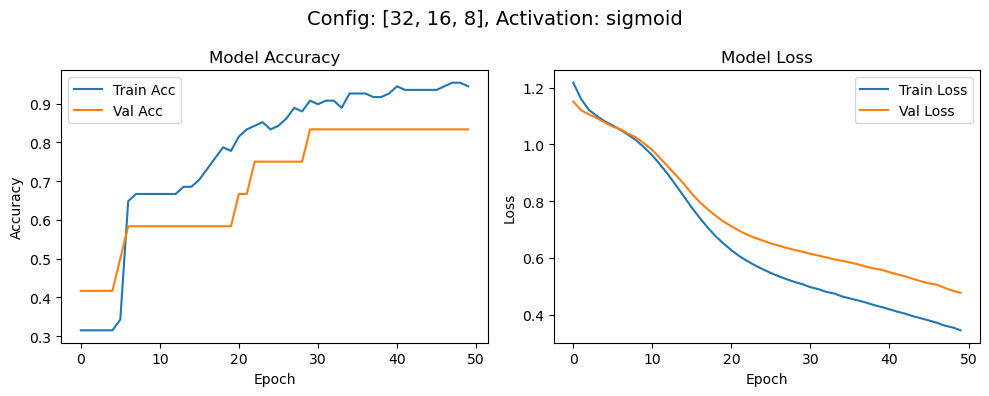

In [21]:
# Plot accuracy and loss
plt.figure(figsize=(10, 4))
plt.suptitle(f"Config: {hidden_layers}, Activation: {activation}", fontsize=14)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
sepal_length = float(input("Sepal length (cm): "))
sepal_width = float(input("Sepal width (cm): "))
petal_length = float(input("Petal length (cm): "))
petal_width = float(input("Petal width (cm): "))
user_input = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
user_input_scaled = scaler.transform(user_input)
# Predict using the last trained model
prediction = model.predict(user_input_scaled)
predicted_class_index = np.argmax(prediction)
predicted_class_name = classes[predicted_class_index]
print(f"\n🌸 Predicted Iris Species: {predicted_class_name}")

Sepal length (cm):  5.1
Sepal width (cm):  3.5
Petal length (cm):  1.5
Petal width (cm):  0.2


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step

🌸 Predicted Iris Species: setosa
